Num GPUs Available:  1
Loading Train data...
Found 107314 files belonging to 13 classes.
Loading Val data...
Found 13325 files belonging to 13 classes.
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'minus', 'point', 'tag']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,621 (1.36 MB)

 Trainable params: 356,621 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


2025-11-29 13:17:39.535702: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:53: Filling up shuffle buffer (this may take a while): 443 of 1000
2025-11-29 13:17:49.528996: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:53: Filling up shuffle buffer (this may take a while): 836 of 1000
2025-11-29 13:17:54.335168: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


3354/3354 ━━━━━━━━━━━━━━━━━━━━ 236s 61ms/step - accuracy: 0.9460 - loss: 0.1797 - val_accuracy: 0.9890 - val_loss: 0.0367
Epoch 2/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9888 - loss: 0.0362 - val_accuracy: 0.9928 - val_loss: 0.0235
Epoch 3/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9920 - val_loss: 0.0255
Epoch 4/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9942 - loss: 0.0182 - val_accuracy: 0.9947 - val_loss: 0.0167
Epoch 5/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9960 - loss: 0.0132 - val_accuracy: 0.9939 - val_loss: 0.0183
Epoch 6/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9951 - val_loss: 0.0154
Epoch 7/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9966 - loss: 0.0112 - val_accuracy: 0.9968 - val_loss: 0.0131
Epoch 8/15
3354/3354 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9966 - loss: 0.0108 - v

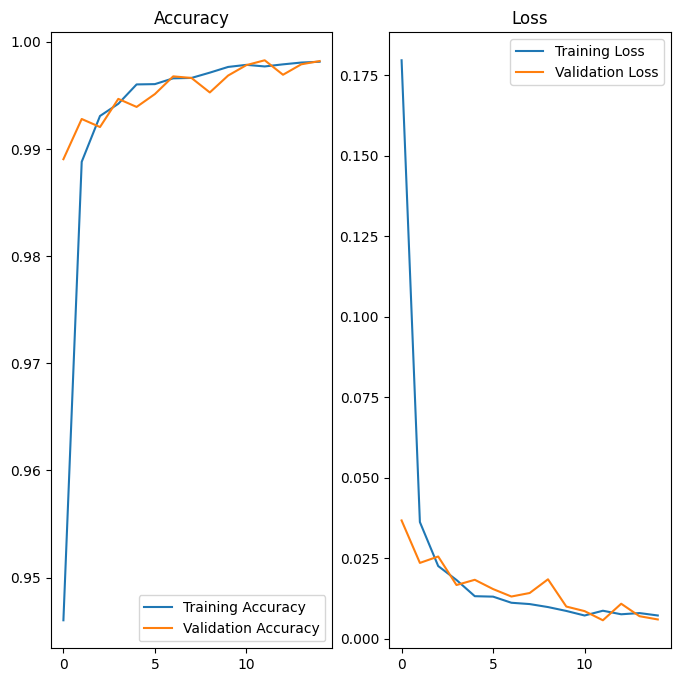

In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- НАЛАШТУВАННЯ ---
DATA_DIR = "final_dataset/classifier"
IMG_SIZE = (32, 32) # Усі символи будемо зводити до цього розміру
BATCH_SIZE = 32
EPOCHS = 15

def main():
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

    # 1. Завантажуємо датасети (з папок)
    print("Loading Train data...")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATA_DIR, "train"),
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale' # Чорно-білого достатньо і швидше
    )

    print("Loading Val data...")
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATA_DIR, "val"),
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode='grayscale'
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Classes found: {class_names}")

    # Кешування для швидкості
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # 2. Створюємо модель CNN
    model = models.Sequential([
        # Рескейлінг [0, 255] -> [0, 1]
        layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2), # Захист від перенавчання

        # Classification Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])

    model.summary()

    # 3. Тренування
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    # 4. Збереження
    model.save("radar_digit_classifier.keras")
    print("✅ Модель збережено як radar_digit_classifier.keras")

    # Зберігаємо список класів, щоб потім знати хто є хто
    with open("classes.txt", "w") as f:
        f.write("\n".join(class_names))

    # Графік навчання
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(EPOCHS)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.savefig('training_plot.png')
    print("Графік навчання збережено в training_plot.png")

if __name__ == "__main__":
    main()